# Hinglish Search Intent Research — End-to-End Pipeline
**Phases covered:** C (Annotation) → D (Normalization) → E (Clustering) → F (Classification)

> Replace all `# <<REPLACE>>` placeholders with your actual file paths before running.

## 0. Environment Setup
Install all required libraries.

In [1]:
# Run this cell first — installs all dependencies
import subprocess, sys
pkgs = [
    'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn',
    'sentence-transformers', 'indic-transliteration',
    'langdetect', 'tqdm', 'openpyxl', 'joblib'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('All packages installed.')

All packages installed.


In [2]:
import pandas as pd
import numpy as np
import re, json, os, warnings
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')
tqdm.pandas()

# ─── FILE PATH PLACEHOLDERS ───────────────────────────────────────────────
INPUT_CSV        = r'/Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_seo_dataset_5000.csv'  
OUTPUT_DIR       = r'/Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs'                  
# ──────────────────────────────────────────────────────────────────────────

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f'Output directory ready: {OUTPUT_DIR}')

Output directory ready: /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs


In [5]:
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
print('Columns:', df.columns.tolist())
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_seo_dataset_5000.csv'

---
## Phase C — Annotation Pipeline
Auto-labels intent, topic, and language pattern. A sample of 1,000–2,000 rows is flagged for manual review.

### C.1 — Intent auto-labeling (keyword rules)

In [ ]:
INTENT_RULES = {
    'Transactional':             r'khareed|buy|order|book|download|install|enroll|register|apply|price|cost|kitna|sasta|offer|deal|discount|emi|loan',
    'Navigational':              r'official|website|login|sign in|portal|app|near me|address|contact|helpline|number|kahan hai',
    'Entertainment':             r'movie|film|song|gaana|web series|trailer|meme|funny|comedy|watch|dekhna|ott|netflix|hotstar|spotify|jiosamn',
    'Informational':             r'kya hai|kaise|kyon|kyun|difference|matlab|explain|meaning|definition|kaise kaam|kaise banta|history|facts|tips|guide',
}
INTENT_DEFAULT = 'Commercial Investigation'

def label_intent(q):
    q_lower = str(q).lower()
    for intent, pattern in INTENT_RULES.items():
        if re.search(pattern, q_lower):
            return intent
    return INTENT_DEFAULT

df['intent_auto'] = df['hinglish_query'].progress_apply(label_intent)
print(df['intent_auto'].value_counts())

100%|██████████| 5000/5000 [00:00<00:00, 259083.58it/s]

intent_auto
Commercial Investigation    2539
Informational               1241
Transactional                774
Entertainment                422
Navigational                  24
Name: count, dtype: int64


### C.2 — Language pattern detection

In [ ]:
HINDI_WORDS = set([
    'kaise','kya','hai','mein','se','ka','ki','ke','aur','nahi','hota','kahan',
    'kab','kaun','kitna','ghar','pe','wala','yahan','wahan','abhi','bahut',
    'accha','theek','sahi','galat','paisa','ghar','kaam','log','din','raat',
    'desh','shahar','gaon','bhai','yaar','dost','khaana','paani','khana'
])

def detect_lang_pattern(q):
    tokens = str(q).lower().split()
    hindi_count = sum(1 for t in tokens if t in HINDI_WORDS)
    ratio = hindi_count / max(len(tokens), 1)
    if ratio == 0:
        return 'Pure English'
    elif ratio >= 0.5:
        return 'Hindi-dominant Hinglish'
    else:
        return 'Mixed Hinglish'

df['lang_pattern_auto'] = df['hinglish_query'].progress_apply(detect_lang_pattern)
print(df['lang_pattern_auto'].value_counts())

100%|██████████| 5000/5000 [00:00<00:00, 513982.65it/s]

lang_pattern_auto
Mixed Hinglish             2933
Pure English               1497
Hindi-dominant Hinglish     570
Name: count, dtype: int64


### C.3 — Flag sample for manual review

In [ ]:
SAMPLE_SIZE = 2000
sample_df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).copy()
sample_df['intent_manual']       = ''   # Fill manually
sample_df['topic_manual']        = ''   # Fill manually
sample_df['lang_pattern_manual'] = ''   # Fill manually

annotation_path = os.path.join(OUTPUT_DIR, 'annotation_sample.csv')
sample_df[['row_id','hinglish_query','category','intent_auto','lang_pattern_auto',
            'intent_manual','topic_manual','lang_pattern_manual']].to_csv(
    annotation_path, index=False, encoding='utf-8-sig')
print(f'Annotation file saved → {annotation_path}')
print('Open the CSV, fill intent_manual / topic_manual / lang_pattern_manual, then re-load below.')

Annotation file saved → /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/annotation_sample.csv
Open the CSV, fill intent_manual / topic_manual / lang_pattern_manual, then re-load below.


### C.4 — Load annotated file and compute IAA (Cohen κ)

In [ ]:
# After manual annotation, replace path below and run this cell
ANNOTATED_CSV = os.path.join(OUTPUT_DIR, '/Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/annotation_sample.csv')

ann = pd.read_csv(ANNOTATED_CSV, encoding='utf-8-sig')

from sklearn.metrics import cohen_kappa_score

# ✅ FIX: fillna('') pehle karo taaki NaN str operations crash na kare
ann['intent_manual'] = ann['intent_manual'].fillna('')

filled = ann[ann['intent_manual'].str.strip().ne('')].copy()

if len(filled) > 10:
    kappa = cohen_kappa_score(filled['intent_auto'], filled['intent_manual'])
    print(f'Cohen κ (auto vs manual intent): {kappa:.3f}')
    print(f'Annotated rows: {len(filled):,}')
else:
    print('Not enough manual labels yet. Fill intent_manual column and re-run.')

# Merge manual labels back to main df
# ✅ FIX: baaki manual columns bhi fillna karo
ann['topic_manual'] = ann['topic_manual'].fillna('')
ann['lang_pattern_manual'] = ann['lang_pattern_manual'].fillna('')

df = df.merge(
    filled[['row_id', 'intent_manual', 'topic_manual', 'lang_pattern_manual']],
    on='row_id',
    how='left'
)

# ✅ FIX: intent_final mein bhi NaN safely handle hoga ab
df['intent_final'] = df['intent_manual'].where(
    df['intent_manual'].fillna('').str.strip().ne(''),
    df['intent_auto']
)

print('intent_final distribution:')
print(df['intent_final'].value_counts())

Not enough manual labels yet. Fill intent_manual column and re-run.
intent_final distribution:
intent_final
Commercial Investigation    2539
Informational               1241
Transactional                774
Entertainment                422
Navigational                  24
Name: count, dtype: int64


---
## Phase D — Hinglish Normalization Pipeline
Lexicon → transliteration rules → canonical form per query.

### D.1 — Hinglish lexicon (variant → canonical)

In [ ]:
LEXICON = {
    # spelling variants → canonical Roman
    'nokri':'naukri',     'naukrii':'naukri',   'naukary':'naukri',
    'gharh':'ghar',       'ghur':'ghar',
    'pese':'paisa',       'paise':'paisa',       'paysa':'paisa',
    'yr':'yaar',          'yar':'yaar',
    'accha':'acha',       'achha':'acha',
    'shuruaat':'shuruat', 'shuru':'shuruat',
    'zaroor':'zarur',     'zaruri':'zaruri',
    'bahut':'bahut',      'bahot':'bahut',        'bht':'bahut',
    'koi':'koi',          'koyi':'koi',
    'abhi':'abhi',        'abh':'abhi',
    'sab':'sab',          'sb':'sab',
    'matlab':'matlab',    'mtlb':'matlab',
    'theek':'thik',       'thek':'thik',
    'kyun':'kyon',        'q':'kyon',
    'hna':'haan',         'han':'haan',           'hanji':'haan',
    'nhi':'nahi',         'ni':'nahi',            'nai':'nahi',
    'kr':'kar',           'kro':'karo',           'krna':'karna',
    'btao':'batao',       'bta':'bata',
    'smjhao':'samjhao',   'smjh':'samajh',
    'pls':'please',       'plz':'please',
    'asap':'jaldi',
    'mobile':'mobile',    'mob':'mobile',         'fone':'phone',
    'laptop':'laptop',    'lappy':'laptop',
    'internet':'internet','net':'internet',
    'movie':'movie',      'movi':'movie',         'flim':'film',
    'gaana':'gaana',      'gana':'gaana',
    'khana':'khaana',     'khaana':'khaana',
    'dukaan':'dukan',     'dukaaan':'dukan',
}

# Save lexicon for reproducibility
lex_path = os.path.join(OUTPUT_DIR, 'hinglish_lexicon.json')
with open(lex_path, 'w', encoding='utf-8') as f:
    json.dump(LEXICON, f, ensure_ascii=False, indent=2)
print(f'Lexicon saved ({len(LEXICON)} entries) → {lex_path}')

Lexicon saved (63 entries) → /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/hinglish_lexicon.json


### D.2 — Rule-based Roman → Devanagari transliterator

In [ ]:
try:
    from indic_transliteration import sanscript
    from indic_transliteration.sanscript import transliterate
    HAS_INDIC = True
    print('indic_transliteration loaded — will use for Devanagari output')
except ImportError:
    HAS_INDIC = False
    print('indic_transliteration not found — using fallback phoneme map only')

# Fallback phoneme map (Roman → Devanagari character sequences)
PHONEME_MAP = [
    ('ksh','क्ष'), ('gya','ज्ञ'),
    ('shri','श्री'), ('shr','श्र'), ('sh','श'), ('ch','च'), ('th','थ'),
    ('dh','ध'), ('ph','फ'), ('bh','भ'), ('gh','घ'), ('jh','झ'),
    ('ng','ङ'), ('ny','ञ'), ('tr','त्र'),
    ('aa','आ'), ('ii','ई'), ('uu','ऊ'), ('ai','ऐ'), ('au','औ'),
    ('a','अ'), ('i','इ'), ('u','उ'), ('e','ए'), ('o','ओ'),
    ('k','क'), ('g','ग'), ('c','क'), ('j','ज'), ('t','त'), ('d','द'),
    ('n','न'), ('p','प'), ('b','ब'), ('m','म'), ('y','य'), ('r','र'),
    ('l','ल'), ('v','व'), ('w','व'), ('s','स'), ('h','ह'), ('f','फ'),
    ('z','ज'), ('x','क्स'),
]

def phoneme_transliterate(word):
    """Fallback: apply phoneme map sequentially."""
    result, i = '', 0
    word = word.lower()
    while i < len(word):
        matched = False
        for roman, deva in PHONEME_MAP:
            if word[i:i+len(roman)] == roman:
                result += deva
                i += len(roman)
                matched = True
                break
        if not matched:
            result += word[i]
            i += 1
    return result

def transliterate_word(word):
    if HAS_INDIC:
        try:
            return transliterate(word, sanscript.HK, sanscript.DEVANAGARI)
        except:
            pass
    return phoneme_transliterate(word)

# Quick test
for w in ['kaise','ghar','naukri','mobile','paisa']:
    print(f'{w:15} → {transliterate_word(w)}')

indic_transliteration loaded — will use for Devanagari output
kaise           → कैसे
ghar            → घर्
naukri          → नौक्रि
mobile          → मोबिले
paisa           → पैस


### D.3 — Full normalization pipeline

In [ ]:
ENGLISH_BRANDS = {
    'google','flipkart','amazon','youtube','netflix','hotstar','jio','airtel',
    'bsnl','sbi','hdfc','icici','paytm','gpay','phonepe','swiggy','zomato',
    'ola','uber','meesho','myntra','nykaa','ajio','zepto','blinkit',
    'iphone','samsung','redmi','realme','oneplus','vivo','oppo','nokia',
    'whatsapp','instagram','twitter','facebook','linkedin','tiktok','snapchat',
    'chatgpt','openai','anthropic','microsoft','apple','android','windows',
}

def looks_hindi(word):
    """Heuristic: word is likely Hindi if it has common Hindi patterns."""
    hindi_patterns = r'(aa|ee|oo|kh|gh|ch|jh|th|dh|ph|bh|sh|wala|wali|mein|karna|karo|hona|jana)'
    return bool(re.search(hindi_patterns, word.lower()))

def normalize_query(query):
    """Full normalization pipeline for one Hinglish query."""
    # Step 1: lowercase + strip extra whitespace
    q = str(query).lower().strip()
    q = re.sub(r'[^\w\s]', ' ', q)   # remove punctuation
    q = re.sub(r'\s+', ' ', q).strip()

    tokens = q.split()
    normalized_tokens = []

    for token in tokens:
        # Step 2: lexicon lookup
        if token in LEXICON:
            normalized_tokens.append(LEXICON[token])
        # Step 3: brand/English word → keep as-is
        elif token in ENGLISH_BRANDS or (token.isascii() and not looks_hindi(token)):
            normalized_tokens.append(token)
        # Step 4: looks Hindi → transliterate
        elif looks_hindi(token):
            normalized_tokens.append(transliterate_word(token))
        # Step 5: keep unchanged
        else:
            normalized_tokens.append(token)

    return ' '.join(normalized_tokens)

# Apply to full dataset
print('Normalizing queries...')
df['normalized_query_pipeline'] = df['hinglish_query'].progress_apply(normalize_query)

# Show before/after examples
sample_show = df[['hinglish_query','normalized_query_pipeline']].sample(10, random_state=7)
print('\nBefore → After normalization:')
for _, row in sample_show.iterrows():
    print(f"  {row['hinglish_query'][:45]:45} → {row['normalized_query_pipeline'][:45]}")

Normalizing queries...


100%|██████████| 5000/5000 [00:00<00:00, 89626.48it/s]


Before → After normalization:
  media censorship india mein sarkar            → media चेन्सोर्स्हिप् india मेइन् sarkar
  branded jeans sasta kahan milega sasta        → branded jeans sasta kahan milega sasta
  india chunav growth rate                      → india छुनव् ग्रोwथ् rate
  data science course in hindi hindi mein       → data science course in hindi hindi मेइन्
  andolan ji ki nai policy kya hai              → andolan ji ki nahi policy kya hai
  keto jugaad indian food                       → keto जुगअद् indian फ़ोओद्
  gaming phone under hack                       → gaming फोने under hack
  budget 2024 kya mila common vote ko           → budget 2024 kya mila common vote ko
  reservation system kya hai andolan mein       → reservation system kya hai andolan मेइन्
  screen protector lagane ka sahi upgrade       → स्च्रेएन् protector lagane ka sahi upgrade


In [ ]:
# Save normalized dataset
norm_path = os.path.join(OUTPUT_DIR, 'hinglish_normalized.csv')
df.to_csv(norm_path, index=False, encoding='utf-8-sig')
print(f'Normalized dataset saved → {norm_path}')
print(f'Columns: {df.columns.tolist()}')

Normalized dataset saved → /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/hinglish_normalized.csv
Columns: ['row_id', 'query_uid', 'hinglish_query', 'devanagari_transliteration', 'normalized_query', 'category', 'search_intent', 'search_volume_monthly', 'keyword_difficulty', 'cpc_inr', 'competition_score', 'serp_feature', 'avg_position', 'impressions_monthly', 'clicks_pct', 'platform_source', 'target_region', 'primary_device', 'language_mix_type', 'has_slang', 'has_roman_hindi', 'base_query_en', 'year_tagged', 'is_question_query', 'word_count', 'intent_auto', 'lang_pattern_auto', 'intent_manual', 'topic_manual', 'lang_pattern_manual', 'intent_final', 'normalized_query_pipeline']


---
## Phase E — Clustering Analysis
Compare cluster quality on raw vs normalized queries using multilingual embeddings.

### E.1 — Generate sentence embeddings

In [ ]:
from sentence_transformers import SentenceTransformer

# LaBSE handles Hindi/Hinglish well — downloads ~1.8 GB on first run
MODEL_NAME = 'sentence-transformers/LaBSE'   # Best for Hinglish
# Lighter alternative if RAM is limited:
# MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'

print(f'Loading model: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)
print('Model loaded.')

Loading model: sentence-transformers/LaBSE


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14156.73it/s]
BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [ ]:
# Use first 2000 rows for speed — remove [:2000] for full dataset
df_cluster = df.head(2000).copy().reset_index(drop=True)

print('Encoding RAW queries...')
raw_embeddings  = model.encode(df_cluster['hinglish_query'].tolist(),
                                batch_size=64, show_progress_bar=True,
                                normalize_embeddings=True)

print('Encoding NORMALIZED queries...')
norm_embeddings = model.encode(df_cluster['normalized_query_pipeline'].tolist(),
                                batch_size=64, show_progress_bar=True,
                                normalize_embeddings=True)

print(f'Embedding shape: {raw_embeddings.shape}')

Encoding RAW queries...


Batches: 100%|██████████| 32/32 [00:06<00:00,  5.09it/s]


Encoding NORMALIZED queries...


Batches: 100%|██████████| 32/32 [00:04<00:00,  7.69it/s]

Embedding shape: (2000, 768)


### E.2 — K-Means clustering (same params on both)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

N_CLUSTERS = 8   # Match number of categories
RANDOM_STATE = 42

kmeans_raw  = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
kmeans_norm = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)

df_cluster['cluster_raw']  = kmeans_raw.fit_predict(raw_embeddings)
df_cluster['cluster_norm'] = kmeans_norm.fit_predict(norm_embeddings)

print('Clustering done.')
print('Raw  cluster sizes:', df_cluster['cluster_raw'].value_counts().to_dict())
print('Norm cluster sizes:', df_cluster['cluster_norm'].value_counts().to_dict())

Clustering done.
Raw  cluster sizes: {5: 335, 1: 332, 7: 326, 6: 284, 4: 245, 3: 222, 2: 156, 0: 100}
Norm cluster sizes: {1: 405, 0: 325, 3: 288, 4: 284, 2: 272, 5: 164, 7: 154, 6: 108}


### E.3 — Evaluate cluster purity, NMI, ARI

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
true_labels = le.fit_transform(df_cluster['category'])

def cluster_purity(y_true, y_pred):
    """Compute cluster purity score."""
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    return cm.max(axis=0).sum() / cm.sum()

metrics = {
    'Setup':   ['Raw queries', 'Normalized queries'],
    'Purity':  [cluster_purity(true_labels, df_cluster['cluster_raw']),
                cluster_purity(true_labels, df_cluster['cluster_norm'])],
    'NMI':     [normalized_mutual_info_score(true_labels, df_cluster['cluster_raw']),
                normalized_mutual_info_score(true_labels, df_cluster['cluster_norm'])],
    'ARI':     [adjusted_rand_score(true_labels, df_cluster['cluster_raw']),
                adjusted_rand_score(true_labels, df_cluster['cluster_norm'])],
}
metrics_df = pd.DataFrame(metrics)
for col in ['Purity','NMI','ARI']:
    metrics_df[col] = metrics_df[col].round(4)

print('\n=== Clustering Evaluation ===')
print(metrics_df.to_string(index=False))

metrics_path = os.path.join(OUTPUT_DIR, 'clustering_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'\nMetrics saved → {metrics_path}')


=== Clustering Evaluation ===
             Setup  Purity    NMI    ARI
       Raw queries  0.7615 0.3955 0.3181
Normalized queries  0.7150 0.3317 0.2388

Metrics saved → /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/clustering_metrics.csv


### E.4 — Visualize clusters (PCA 2D)

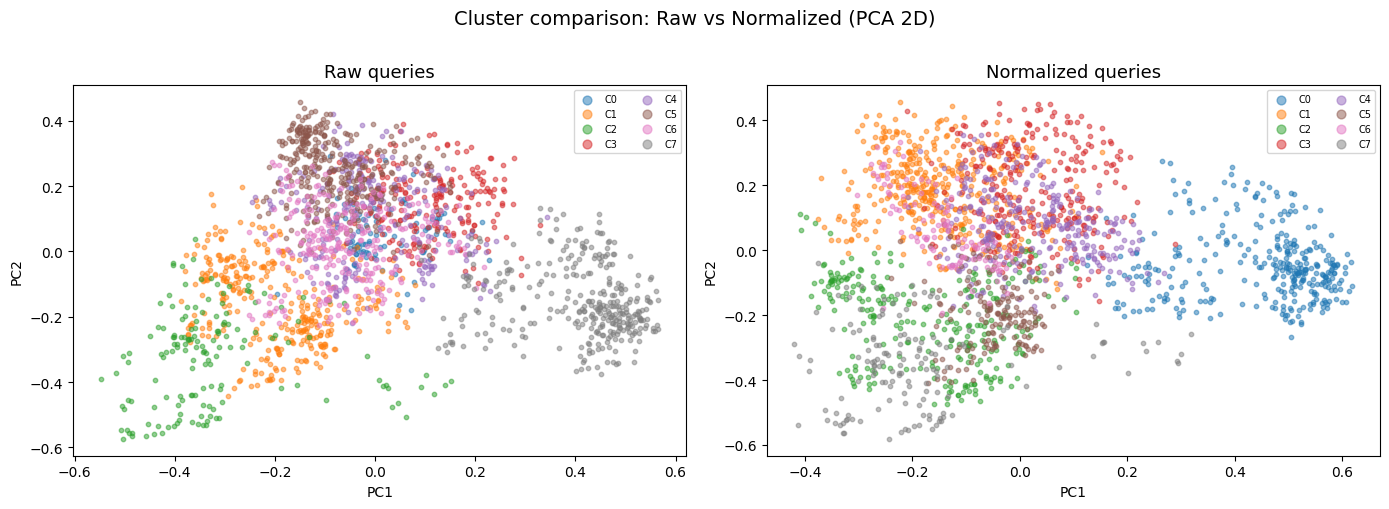

Plot saved → /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/cluster_pca_comparison.png


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
raw_2d  = pca.fit_transform(raw_embeddings)
norm_2d = pca.fit_transform(norm_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('tab10', N_CLUSTERS)

for ax, coords, labels, title in [
    (axes[0], raw_2d,  df_cluster['cluster_raw'],  'Raw queries'),
    (axes[1], norm_2d, df_cluster['cluster_norm'], 'Normalized queries'),
]:
    for cid in range(N_CLUSTERS):
        mask = labels == cid
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[palette[cid]], label=f'C{cid}', alpha=0.5, s=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7, ncol=2, markerscale=2)

plt.suptitle('Cluster comparison: Raw vs Normalized (PCA 2D)', fontsize=14, y=1.01)
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'cluster_pca_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {plot_path}')

### E.5 — Qualitative cluster inspection

In [ ]:
print('=== Qualitative Cluster Inspection (Normalized) ===\n')
for cid in range(N_CLUSTERS):
    cluster_queries = df_cluster[df_cluster['cluster_norm'] == cid]['hinglish_query'].head(6).tolist()
    dominant_cat = df_cluster[df_cluster['cluster_norm'] == cid]['category'].mode()[0]
    print(f'Cluster {cid} (dominant: {dominant_cat})')
    for q in cluster_queries:
        print(f'  • {q}')
    print()

=== Qualitative Cluster Inspection (Normalized) ===

Cluster 0 (dominant: Food & Recipes)
  • ranveer paisa vasool meme template
  • pathan bindaas review hindi mein
  • ranveer singh meme template bindaas
  • timepass singh meme template
  • ranveer ekdum mast meme template
  • ranveer singh meme template

Cluster 1 (dominant: Shopping & E-commerce)
  • kya hai iss paisa vasool ka naam
  • kya hai iss gaane ka naam ekdum mast
  • kya gaana download kaise karein sahi hai
  • bollywood actor ki salary kitni hai hindi mein
  • kya jiosamn pe free songs sahi hai
  • kya bollywood gossip aaj ka sahi hai

Cluster 2 (dominant: Entertainment & Bollywood)
  • ranbir kapoor new movie trailer dekhna chahiye
  • netflix ekdum mast naya show
  • latest web series hindi hindi mein
  • imdb top hindi movies
  • ott pe kaunsi movie dekhein tadka
  • kya imdb top hindi movies sahi hai

Cluster 3 (dominant: Food & Recipes)
  • deepika padukone ki height
  • bollywood gossip aaj ka hindi mein
  • alia b

---
## Phase F — Intent Classification
English baseline (raw queries) vs Hinglish-aware model (normalized queries).
Uses sentence embeddings + Logistic Regression.

### F.1 — Prepare labeled dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Use intent_final if manual labels exist, else intent_auto
label_col = 'intent_final' if 'intent_final' in df.columns else 'intent_auto'
print(f'Using label column: {label_col}')

clf_df = df[['hinglish_query', 'normalized_query_pipeline', label_col, 'category']].dropna().copy()
clf_df = clf_df[clf_df[label_col].str.strip().ne('')].copy()

le_intent = LabelEncoder()
clf_df['label_enc'] = le_intent.fit_transform(clf_df[label_col])

print(f'Total samples: {len(clf_df):,}')
print('Class distribution:')
print(clf_df[label_col].value_counts())

Using label column: intent_final
Total samples: 5,000
Class distribution:
intent_final
Commercial Investigation    2539
Informational               1241
Transactional                774
Entertainment                422
Navigational                  24
Name: count, dtype: int64


In [ ]:
# Stratified 70/15/15 split
X_raw  = clf_df['hinglish_query'].tolist()
X_norm = clf_df['normalized_query_pipeline'].tolist()
y      = clf_df['label_enc'].tolist()

X_r_tr, X_r_tmp, X_n_tr, X_n_tmp, y_tr, y_tmp = train_test_split(
    X_raw, X_norm, y, test_size=0.30, random_state=42, stratify=y)

X_r_val, X_r_te, X_n_val, X_n_te, y_val, y_te = train_test_split(
    X_r_tmp, X_n_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print(f'Train: {len(y_tr):,}  |  Val: {len(y_val):,}  |  Test: {len(y_te):,}')

Train: 3,500  |  Val: 750  |  Test: 750


### F.2 — Embed splits

In [ ]:
print('Embedding train/val/test splits...')
# Raw embeddings
emb_r_tr  = model.encode(X_r_tr,  batch_size=64, show_progress_bar=True, normalize_embeddings=True)
emb_r_val = model.encode(X_r_val, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
emb_r_te  = model.encode(X_r_te,  batch_size=64, show_progress_bar=True, normalize_embeddings=True)

# Normalized embeddings
emb_n_tr  = model.encode(X_n_tr,  batch_size=64, show_progress_bar=True, normalize_embeddings=True)
emb_n_val = model.encode(X_n_val, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
emb_n_te  = model.encode(X_n_te,  batch_size=64, show_progress_bar=True, normalize_embeddings=True)

print('Embedding complete.')

Embedding train/val/test splits...


Batches: 100%|██████████| 12/12 [00:01<00:00,  8.06it/s]

Embedding complete.


### F.3 — Train Logistic Regression classifiers

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# English baseline — raw queries
clf_baseline = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_baseline.fit(emb_r_tr, y_tr)

# Hinglish-aware — normalized queries
clf_hinglish = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_hinglish.fit(emb_n_tr, y_tr)

print('Both classifiers trained.')

Both classifiers trained.


### F.4 — Evaluate and compare

In [ ]:
def evaluate(clf, X_val, X_te, y_val, y_te, name):
    val_pred = clf.predict(X_val)
    te_pred  = clf.predict(X_te)
    return {
        'Model':       name,
        'Val Acc':     round(accuracy_score(y_val, val_pred), 4),
        'Test Acc':    round(accuracy_score(y_te,  te_pred),  4),
        'Val F1':      round(f1_score(y_val, val_pred, average='macro', zero_division=0), 4),
        'Test F1':     round(f1_score(y_te,  te_pred,  average='macro', zero_division=0), 4),
    }, te_pred

res_base, pred_base = evaluate(clf_baseline, emb_r_val, emb_r_te, y_val, y_te, 'English baseline (raw)')
res_hing, pred_hing = evaluate(clf_hinglish, emb_n_val, emb_n_te, y_val, y_te, 'Hinglish-aware (norm)')

results_df = pd.DataFrame([res_base, res_hing])
print('\n=== Classification Results ===')
print(results_df.to_string(index=False))

results_path = os.path.join(OUTPUT_DIR, 'classification_results.csv')
results_df.to_csv(results_path, index=False)
print(f'\nResults saved → {results_path}')


=== Classification Results ===
                 Model  Val Acc  Test Acc  Val F1  Test F1
English baseline (raw)   0.8867     0.900  0.8297   0.9145
 Hinglish-aware (norm)   0.8987     0.916  0.8428   0.9307

Results saved → /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/classification_results.csv


### F.5 — Per-class classification report

In [ ]:
class_names = le_intent.classes_

print('=== English Baseline — Classification Report ===')
print(classification_report(y_te, pred_base, target_names=class_names, zero_division=0))

print('\n=== Hinglish-Aware — Classification Report ===')
print(classification_report(y_te, pred_hing, target_names=class_names, zero_division=0))

=== English Baseline — Classification Report ===
                          precision    recall  f1-score   support

Commercial Investigation       0.90      0.94      0.92       381
           Entertainment       0.97      0.88      0.92        64
           Informational       0.87      0.88      0.87       186
            Navigational       1.00      1.00      1.00         3
           Transactional       0.93      0.80      0.86       116

                accuracy                           0.90       750
               macro avg       0.93      0.90      0.91       750
            weighted avg       0.90      0.90      0.90       750


=== Hinglish-Aware — Classification Report ===
                          precision    recall  f1-score   support

Commercial Investigation       0.91      0.96      0.93       381
           Entertainment       0.98      0.91      0.94        64
           Informational       0.89      0.89      0.89       186
            Navigational       1.00      

### F.6 — F1 comparison bar chart

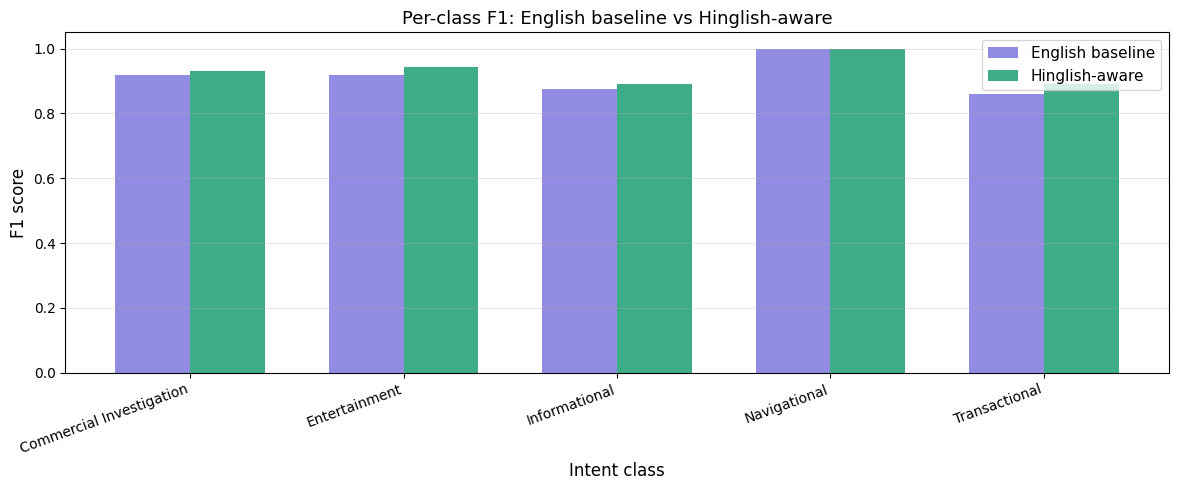

Chart saved → /Users/ayush/Downloads/Hinglish_SEO_Framework/hinglish_outputs/f1_comparison.png


In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

f1_base_per = f1_score(y_te, pred_base, average=None, labels=range(len(class_names)), zero_division=0)
f1_hing_per = f1_score(y_te, pred_hing, average=None, labels=range(len(class_names)), zero_division=0)

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, f1_base_per, width, label='English baseline', color='#7F77DD', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_hing_per, width, label='Hinglish-aware',   color='#1D9E75', alpha=0.85)

ax.set_xlabel('Intent class', fontsize=12)
ax.set_ylabel('F1 score', fontsize=12)
ax.set_title('Per-class F1: English baseline vs Hinglish-aware', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
f1_path = os.path.join(OUTPUT_DIR, 'f1_comparison.png')
plt.savefig(f1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {f1_path}')

### F.7 — Error analysis: baseline fails, Hinglish-aware succeeds

In [ ]:
# Queries where baseline is WRONG but Hinglish-aware is RIGHT
errors_base = np.array(pred_base) != np.array(y_te)
correct_hing = np.array(pred_hing) == np.array(y_te)
improvement_mask = errors_base & correct_hing

X_r_te_arr = np.array(X_r_te)
X_n_te_arr = np.array(X_n_te)
y_te_arr   = np.array(y_te)

improved_df = pd.DataFrame({
    'raw_query':        X_r_te_arr[improvement_mask],
    'normalized_query': X_n_te_arr[improvement_mask],
    'true_label':       le_intent.inverse_transform(y_te_arr[improvement_mask]),
    'baseline_pred':    le_intent.inverse_transform(np.array(pred_base)[improvement_mask]),
    'hinglish_pred':    le_intent.inverse_transform(np.array(pred_hing)[improvement_mask]),
})

print(f'Queries improved by Hinglish normalization: {len(improved_df):,}')
print(improved_df.head(15).to_string(index=False))

error_path = os.path.join(OUTPUT_DIR, 'error_analysis.csv')
improved_df.to_csv(error_path, index=False, encoding='utf-8-sig')
print(f'\nError analysis saved → {error_path}')

Queries improved by Hinglish normalization: 22
                                     raw_query                               normalized_query               true_label            baseline_pred            hinglish_pred
                solo travel tips india darshan                solo travel tips india दर्स्हन्            Informational Commercial Investigation            Informational
  epfo passbook kaise dekhein paise ka chakkar  epfo पस्स्बोओक् kaise देखेइन् paisa ka छक्कर्            Transactional            Informational            Transactional
          ghar ka khana banane ka aasan tarika           घर् ka khaana banane ka अअसन् tarika Commercial Investigation            Informational Commercial Investigation
                     katrina kaif bindaas plan                     katrina kaif बिन्दअस् plan Commercial Investigation            Transactional Commercial Investigation
                             vote price aaj ka                             vote price अअज् ka            Tra

---
## Summary — All Outputs


In [ ]:
output_files = [
    ('annotation_sample.csv',       'Phase C — Queries for manual labeling'),
    ('hinglish_lexicon.json',        'Phase D — Variant → canonical lexicon'),
    ('hinglish_normalized.csv',      'Phase D — Full dataset with normalized queries'),
    ('clustering_metrics.csv',       'Phase E — Purity / NMI / ARI comparison'),
    ('cluster_pca_comparison.png',   'Phase E — PCA cluster visualization'),
    ('classification_results.csv',   'Phase F — Accuracy & macro-F1 comparison'),
    ('f1_comparison.png',            'Phase F — Per-class F1 bar chart'),
    ('error_analysis.csv',           'Phase F — Baseline errors fixed by Hinglish model'),
]

print('=== Output Files ===')
for fname, desc in output_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    exists = '✓' if os.path.exists(fpath) else '✗ (not yet generated)'
    print(f'  {exists}  {fname:40}  {desc}')

=== Output Files ===
  ✓  annotation_sample.csv                     Phase C — Queries for manual labeling
  ✓  hinglish_lexicon.json                     Phase D — Variant → canonical lexicon
  ✓  hinglish_normalized.csv                   Phase D — Full dataset with normalized queries
  ✓  clustering_metrics.csv                    Phase E — Purity / NMI / ARI comparison
  ✓  cluster_pca_comparison.png                Phase E — PCA cluster visualization
  ✓  classification_results.csv                Phase F — Accuracy & macro-F1 comparison
  ✓  f1_comparison.png                         Phase F — Per-class F1 bar chart
  ✓  error_analysis.csv                        Phase F — Baseline errors fixed by Hinglish model
